## **Cross Validation para escolha de um $k$ ótimo para o KNN**

Essa técnica consiste em estimar o erro de generalização do modelo a partir de múltiplas divisões do conjunto de dados disponíveis.


### **Particionamento dos dados**

Seja $\mathcal{D}$ o conjunto de dados observados:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
$$

Vamos dividir $\mathcal{D}$ em $T$ subconjuntos de mesmo tamanho:
$$
\{\mathcal{F}_i\}_{i=1}^{T}
$$

tal que

*   $\mathcal{F}_{i} \neq \emptyset \quad \forall i \leq T $
*   $|\mathcal{F}_{1}| = |\mathcal{F}_{2}| = \dots = |\mathcal{F}_{T}|$

*   $\mathcal{F}_{i} \cap \mathcal{F}_{j} = \emptyset \quad \forall i \neq j$
*   $\displaystyle\bigcup_{i = 1}^{T} \mathcal{F}_{i} = \mathcal{D}$

### **Partições de Treino e de Validação**

Como visto, para cada $k \in \mathcal{K}$, realizamos $T$ experimentos onde no experimento $j$:

##### **Conjunto de validação:**

$$
\mathcal{D}^{(j)}_{val} = \mathcal{F}_j
$$

##### **Conjunto de treino:**

$$
\mathcal{D}^{(j)}_{train} = \mathcal{D} \setminus \mathcal{F}_j
$$

### **Valores de $k$ e Experimentos**

Seja $\mathcal{K}$ o conjunto dos valores de $k$ para análise:

$$
\mathcal{K} = \{k_i\}_{i=1}^{M} \quad (M \leq N)
$$

Para cada $k \in \mathcal{K}$ vamos realizar $T$ experimentos. No experimento $j$, treinamos um modelo

$$
\hat{f}^{(j)}_k : \mathcal{X} \rightarrow \mathcal{Y}
$$

utilizando o conjunto $\mathcal{D}^{(j)}_{train}$ e calculamos o erro no conjunto de validação:

$$
R_j (k) = \dfrac{1}{|\mathcal{D}^{(j)}_{val}|} \sum_{\mathbf{x}_i,\, y_i \,\in\, \mathcal{D}^{(j)}_{val}} \mathcal{L}\!\left(y_i,\, \hat{f}^{(j)}_k(\mathbf{x}_i)\right)
$$

onde $\mathcal{L} : \mathcal{Y} \times \mathcal{Y} \rightarrow \mathbb{R}$ é a função de perda apropriada.

### **Erro Médio (Cross-Validation)**

Definimos o erro médio como a média dos erros nos $T$ experimentos:

$$
R_{CV}(k) = \dfrac{1}{T} \sum_{j=1}^{T} R_j (k)
$$

### **Escolha do $k$ ótimo**

O valor ótimo de $k$ é definido como:

$$
\hat{k} = \arg\min_k R_{CV}(k)
$$

### **Função de perda $\mathcal{L}(.,.)$**

A função $\mathcal{L}(.,.)$ depende do tipo de tarefa realizada pelo KNN:

#### **Classificação**

Em problemas de classificação, uma escolha comum é a **0-1 Loss**:

$$
\mathcal{L}(y, \hat{y}) =
\begin{cases}
0, & \text{se } y = \hat{y} \\
1, & \text{se } y \neq \hat{y}
\end{cases}
$$

#### **Regressão**

Em problemas de regressão, uma escolha comum é a **Quadratic Loss**:

$$
\mathcal{L}(y, \hat{y}) = (\hat{y} - y)^{2}
$$

## **Implementação da Validação Cruzada para o KNN**

Vamos usar **Cross Validation** para encontrar o melhor $k$ no KNN, avaliando a acurácia de cada $k$ na classificação do [**Iris Flower Dataset**](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (150, 4)
Shape de y: (150,)


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [5]:
from collections import Counter

def predict_classification(X_train, y_train, z, k):

    distances = []

    for i in range(len(X_train)):
        dist = np.sqrt(np.sum((z - X_train[i]) ** 2))
        distances.append(dist)

    distances = np.array(distances)

    neighbor_idx = np.argsort(distances)[:k]

    neighbor_labels = y_train[neighbor_idx]

    most_common = Counter(neighbor_labels).most_common(1)

    return most_common[0][0]


def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for z in X_test:
        pred = predict_classification(X_train, y_train, z, k)
        predictions.append(pred)

    return np.array(predictions)

In [6]:
from sklearn.model_selection import StratifiedKFold

def folds(T):
  skf = StratifiedKFold(n_splits=T, shuffle=True, random_state=42)
  return skf

def error_rate(y_real, y_pred):
    return np.mean(y_real != y_pred)

In [7]:
def cross_validation(K, skf, X, y):

    means = []
    stds = []

    for k in K:

        errors = []

        for j, (train_idx, test_idx) in enumerate(skf.split(X, y)):

            X_train = X[train_idx]
            y_train = y[train_idx]

            X_test = X[test_idx]
            y_test = y[test_idx]

            y_pred = knn_predict(X_train, y_train, X_test, k)

            acc = error_rate(y_test, y_pred)

            errors.append(acc)

        means.append(np.mean(errors))
        stds.append(np.std(errors))

        print(f"k = {k} | mean error = {np.mean(errors):.4f} | std = {np.std(errors):.4f}")

    means = np.array(means)

    best_k = K[np.argmin(means)]

    return best_k, means, stds

In [8]:
K = [1, 3, 5, 7, 9]
T = 5

skf = folds(T)

best_k, means, stds = cross_validation(K, skf, X, y)

k = 1 | mean error = 0.0600 | std = 0.0533
k = 3 | mean error = 0.0600 | std = 0.0646
k = 5 | mean error = 0.0333 | std = 0.0365
k = 7 | mean error = 0.0400 | std = 0.0327
k = 9 | mean error = 0.0533 | std = 0.0340


In [9]:
print("Melhor K:", best_k)

Melhor K: 5


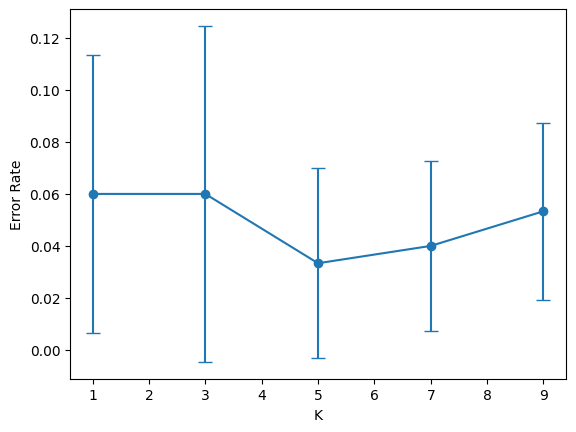

In [10]:
import matplotlib.pyplot as plt

plt.errorbar(K, means, yerr=stds, marker='o', capsize=5)
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()